# Question 1: Sunflower Circle Detection using Blob Detection

Image shape: (360, 360, 3)
Image dtype: uint8


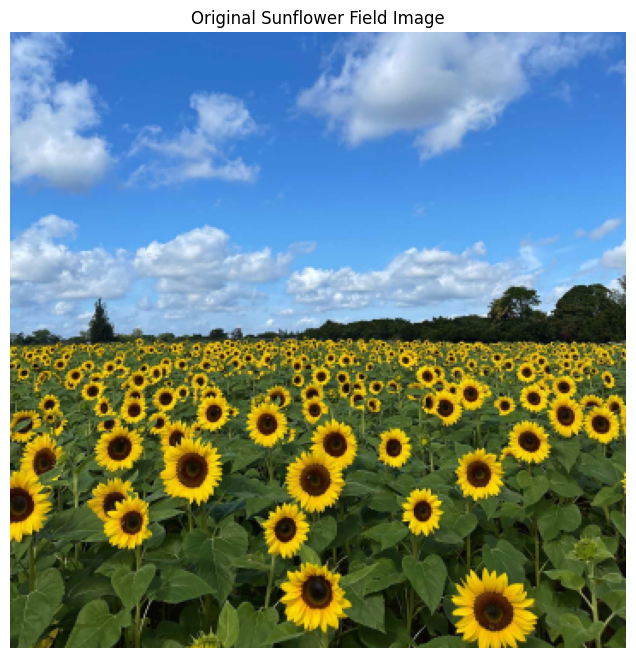

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.ndimage import gaussian_laplace
import warnings
warnings.filterwarnings('ignore')

im = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4)
im_rgb = cv.cvtColor(im, cv.COLOR_BGR2RGB)
im_gray = cv.cvtColor(im, cv.COLOR_BGR2GRAY)

print(f"Image shape: {im.shape}")
print(f"Image dtype: {im.dtype}")

plt.figure(figsize=(12, 8))
plt.imshow(im_rgb)
plt.title('Original Sunflower Field Image')
plt.axis('off')
plt.show()


In [ ]:
def laplacian_of_gaussian(image, sigma):
    blurred = cv.GaussianBlur(image, (0, 0), sigma)
    log_image = cv.Laplacian(blurred, cv.CV_64F)
    return log_image

def detect_blobs_log(image, sigma_min=1.0, sigma_max=20.0, num_scales=15, threshold=0.02):
    height, width = image.shape
    sigma_values = np.logspace(np.log10(sigma_min), np.log10(sigma_max), num_scales)
    
    scale_space = []
    blob_candidates = []
    
    print(f"Testing {num_scales} scales with sigma values:")
    print(f"Range: [{sigma_min:.2f}, {sigma_max:.2f}]")
    print(f"Values: {sigma_values}")
    
    for i, sigma in enumerate(sigma_values):
        log_response = laplacian_of_gaussian(image, sigma)
        scale_space.append(log_response)
        local_minima = ndimage.minimum_filter(log_response, size=3) == log_response
        dark_blobs = np.where((local_minima) & (log_response < -threshold * np.std(log_response)))
        
        local_maxima = ndimage.maximum_filter(log_response, size=3) == log_response
        light_blobs = np.where((local_maxima) & (log_response > threshold * np.std(log_response)))
        
        for y, x in zip(dark_blobs[0], dark_blobs[1]):
            if 5 <= x < width-5 and 5 <= y < height-5:
                blob_candidates.append((x, y, sigma, log_response[y, x]))
                
        for y, x in zip(light_blobs[0], light_blobs[1]):
            if 5 <= x < width-5 and 5 <= y < height-5:
                blob_candidates.append((x, y, sigma, log_response[y, x]))
    
    return blob_candidates, sigma_values, scale_space

blob_candidates, sigma_values, scale_space = detect_blobs_log(im_gray, 
                                                             sigma_min=2.0, 
                                                             sigma_max=25.0, 
                                                             num_scales=20,
                                                             threshold=0.015)

print(f"\nDetected {len(blob_candidates)} blob candidates")
print(f"Sigma range used: [{sigma_values[0]:.2f}, {sigma_values[-1]:.2f}]")


Testing 20 scales with sigma values:
Range: [2.00, 25.00]
Values: [ 2.          2.28434714  2.60912092  2.98006896  3.403756    3.88768013
  4.44040549  5.07171379  5.79277744  6.61635729  7.55702841  8.63143811
  9.85860048 11.26023289 12.86114039 14.68965462 16.77813524 19.16354261
 21.88809186 25.        ]

Detected 917098 blob candidates
Sigma range used: [2.00, 25.00]


In [ ]:
def non_maximum_suppression(blob_candidates, min_distance=20):
    if not blob_candidates:
        return []
    
    blob_candidates.sort(key=lambda x: abs(x[3]), reverse=True)
    
    filtered_blobs = []
    
    for blob in blob_candidates:
        x, y, sigma, response = blob
        too_close = False
        for selected_blob in filtered_blobs:
            sx, sy, _, _ = selected_blob
            distance = np.sqrt((x - sx)**2 + (y - sy)**2)
            if distance < min_distance:
                too_close = True
                break
        
        if not too_close:
            filtered_blobs.append(blob)
    
    return filtered_blobs

def blob_to_circle_params(blob):
    x, y, sigma, response = blob
    radius = np.sqrt(2) * sigma
    return (x, y, radius)

filtered_blobs = non_maximum_suppression(blob_candidates, min_distance=15)

print(f"After non-maximum suppression: {len(filtered_blobs)} blobs")

detected_circles = []
for blob in filtered_blobs:
    circle_params = blob_to_circle_params(blob)
    detected_circles.append(circle_params)

detected_circles.sort(key=lambda x: x[2], reverse=True)

print(f"\nDetected {len(detected_circles)} circles")
print("Circle parameters (x, y, radius):")
for i, (x, y, radius) in enumerate(detected_circles[:10]):
    print(f"Circle {i+1}: center=({x:.1f}, {y:.1f}), radius={radius:.1f}")


After non-maximum suppression: 403 blobs

Detected 403 circles
Circle parameters (x, y, radius):
Circle 1: center=(287.0, 70.0), radius=35.4
Circle 2: center=(354.0, 63.0), radius=31.0
Circle 3: center=(177.0, 65.0), radius=31.0
Circle 4: center=(150.0, 354.0), radius=23.7
Circle 5: center=(278.0, 149.0), radius=23.7
Circle 6: center=(314.0, 82.0), radius=15.9
Circle 7: center=(245.0, 39.0), radius=12.2
Circle 8: center=(263.0, 80.0), radius=12.2
Circle 9: center=(55.0, 108.0), radius=9.4
Circle 10: center=(260.0, 115.0), radius=9.4


In [ ]:
print("="*60)
print("REPORT: Parameters of the Largest Detected Circles")
print("="*60)

if detected_circles:
    print(f"\nTotal circles detected: {len(detected_circles)}")
    print(f"\nTop 5 largest circles:")
    print("-" * 50)
    
    for i, (x, y, radius) in enumerate(detected_circles[:5]):
        print(f"Circle {i+1}:")
        print(f"  Center coordinates: ({x:.2f}, {y:.2f})")
        print(f"  Radius: {radius:.2f} pixels")
        print(f"  Diameter: {2*radius:.2f} pixels")
        print()
    
    print("="*60)
    print("REPORT: Range of σ (sigma) values used")
    print("="*60)
    print(f"Minimum σ: {sigma_values[0]:.2f}")
    print(f"Maximum σ: {sigma_values[-1]:.2f}")
    print(f"Number of scales tested: {len(sigma_values)}")
    print(f"σ values: {sigma_values}")
    
    min_radius = np.sqrt(2) * sigma_values[0]
    max_radius = np.sqrt(2) * sigma_values[-1]
    print(f"\nCorresponding radius range:")
    print(f"Minimum radius: {min_radius:.2f} pixels")
    print(f"Maximum radius: {max_radius:.2f} pixels")
    
else:
    print("No circles detected!")


REPORT: Parameters of the Largest Detected Circles

Total circles detected: 403

Top 5 largest circles:
--------------------------------------------------
Circle 1:
  Center coordinates: (287.00, 70.00)
  Radius: 35.36 pixels
  Diameter: 70.71 pixels

Circle 2:
  Center coordinates: (354.00, 63.00)
  Radius: 30.95 pixels
  Diameter: 61.91 pixels

Circle 3:
  Center coordinates: (177.00, 65.00)
  Radius: 30.95 pixels
  Diameter: 61.91 pixels

Circle 4:
  Center coordinates: (150.00, 354.00)
  Radius: 23.73 pixels
  Diameter: 47.46 pixels

Circle 5:
  Center coordinates: (278.00, 149.00)
  Radius: 23.73 pixels
  Diameter: 47.46 pixels

REPORT: Range of σ (sigma) values used
Minimum σ: 2.00
Maximum σ: 25.00
Number of scales tested: 20
σ values: [ 2.          2.28434714  2.60912092  2.98006896  3.403756    3.88768013
  4.44040549  5.07171379  5.79277744  6.61635729  7.55702841  8.63143811
  9.85860048 11.26023289 12.86114039 14.68965462 16.77813524 19.16354261
 21.88809186 25.        ]

Co

error: OpenCV(4.12.0) :-1: error: (-5:Bad argument) in function 'putText'
> Overload resolution failed:
>  - Can't parse 'org'. Sequence item with index 1 has a wrong type
>  - Can't parse 'org'. Sequence item with index 1 has a wrong type


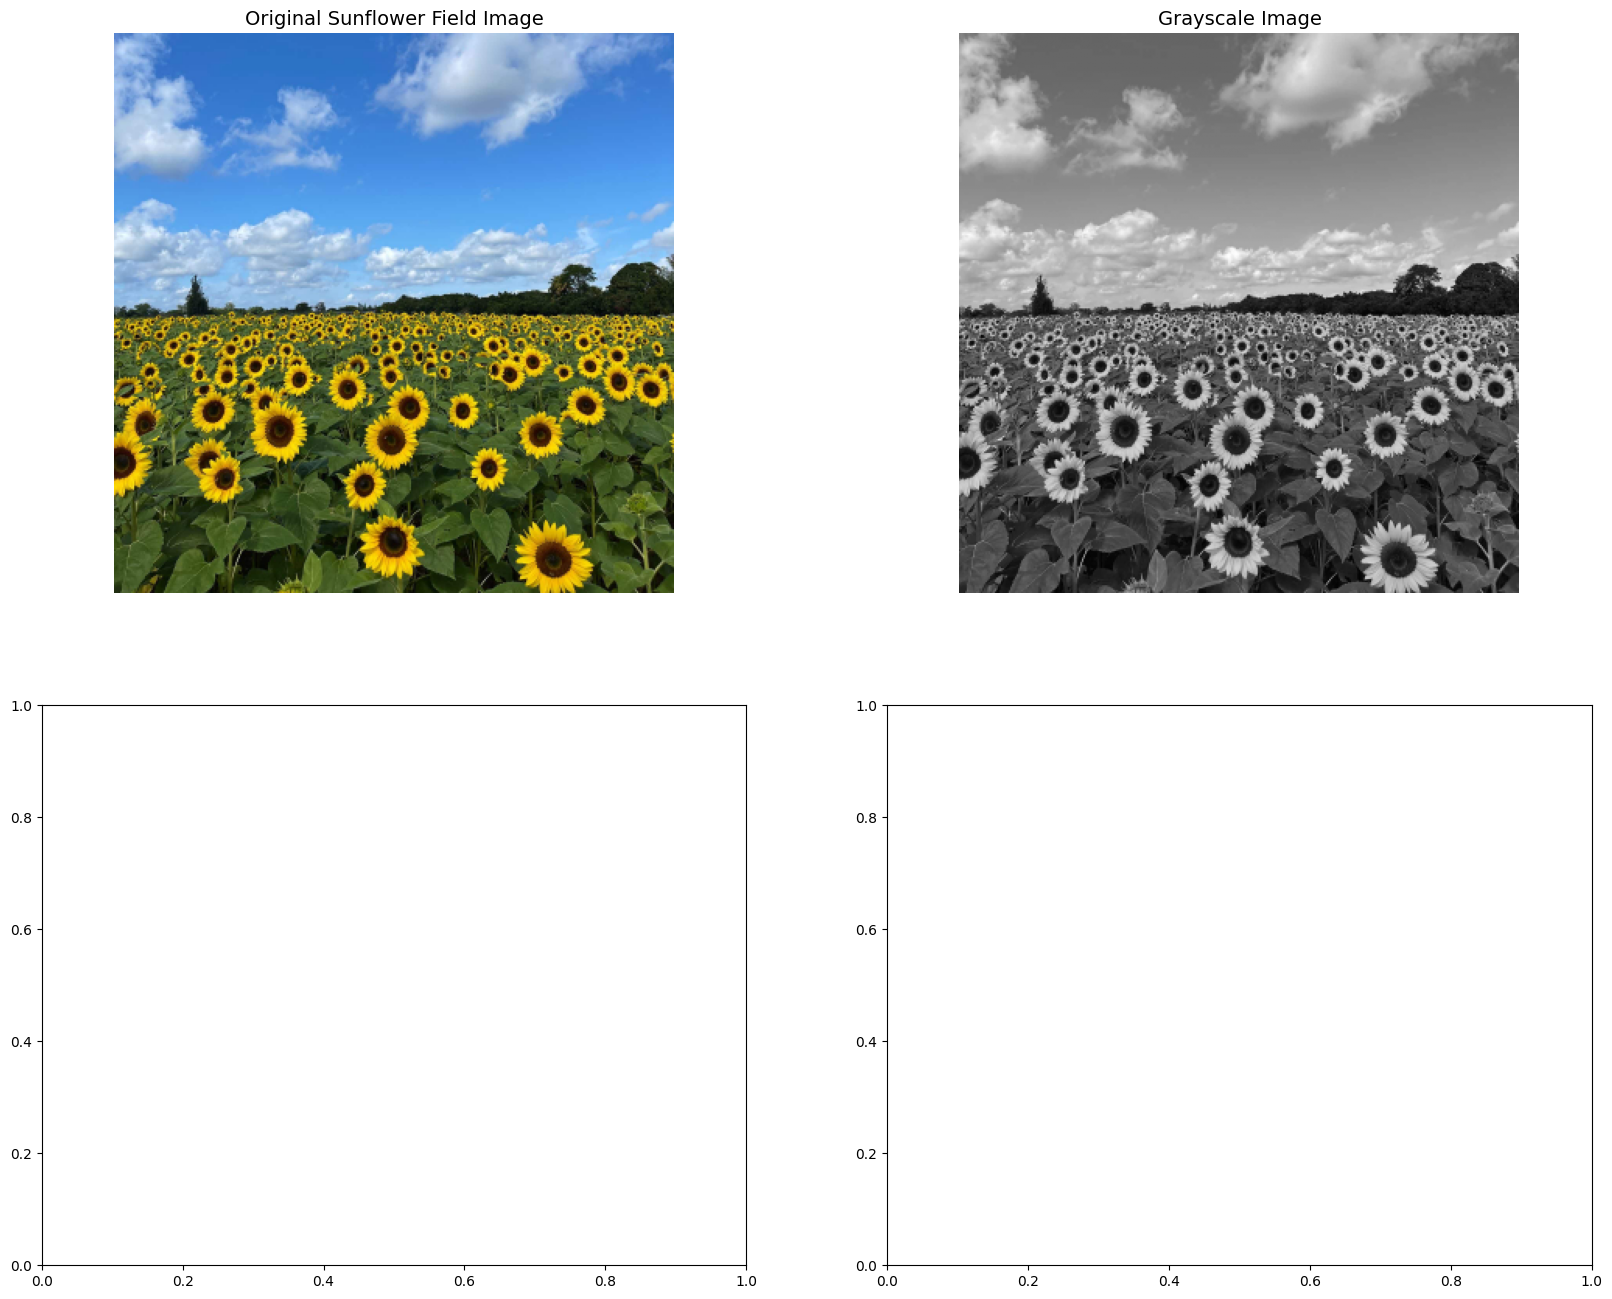

In [ ]:

def draw_circles_on_image(image, circles, max_circles=20, color=(0, 255, 0), thickness=2):
    result_image = image.copy()
    
    for i, (x, y, radius) in enumerate(circles[:max_circles]):
        cv.circle(result_image, (int(x), int(y)), int(radius), color, thickness)
        cv.circle(result_image, (int(x), int(y)), 3, (0, 0, 255), -1)
        cv.putText(result_image, f"{i+1}", (int(x)-10, int(y)-radius-10), 
                  cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    
    return result_image

fig, axes = plt.subplots(2, 2, figsize=(20, 16))

axes[0, 0].imshow(im_rgb)
axes[0, 0].set_title('Original Sunflower Field Image', fontsize=14)
axes[0, 0].axis('off')

axes[0, 1].imshow(im_gray, cmap='gray')
axes[0, 1].set_title('Grayscale Image', fontsize=14)
axes[0, 1].axis('off')

result_color = draw_circles_on_image(im, detected_circles, max_circles=15, color=(0, 255, 0), thickness=2)
result_color_rgb = cv.cvtColor(result_color, cv.COLOR_BGR2RGB)
axes[1, 0].imshow(result_color_rgb)
axes[1, 0].set_title('Detected Circles (Color)', fontsize=14)
axes[1, 0].axis('off')

result_gray = draw_circles_on_image(cv.cvtColor(im_gray, cv.COLOR_GRAY2BGR), detected_circles, 
                                   max_circles=15, color=(0, 255, 0), thickness=2)
result_gray_rgb = cv.cvtColor(result_gray, cv.COLOR_BGR2RGB)
axes[1, 1].imshow(result_gray_rgb)
axes[1, 1].set_title('Detected Circles (Grayscale)', fontsize=14)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

cv.imwrite('output_sunflower_circles_color.png', result_color)
cv.imwrite('output_sunflower_circles_gray.png', result_gray)

print("Results saved as:")
print("- output_sunflower_circles_color.png")
print("- output_sunflower_circles_gray.png")


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

scale_indices = [0, len(sigma_values)//4, len(sigma_values)//2, 3*len(sigma_values)//4, -2, -1]
scale_indices = [i for i in scale_indices if i < len(scale_space)]

for i, scale_idx in enumerate(scale_indices):
    row = i // 3
    col = i % 3
    
    if row < 2 and col < 3:
        sigma = sigma_values[scale_idx]
        log_response = scale_space[scale_idx]
        
        log_display = np.abs(log_response)
        log_display = (log_display - log_display.min()) / (log_display.max() - log_display.min())
        
        axes[row, col].imshow(log_display, cmap='hot')
        axes[row, col].set_title(f'LoG Response (σ={sigma:.2f})', fontsize=12)
        axes[row, col].axis('off')

plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, scale_idx in enumerate(scale_indices):
    plt.subplot(2, 3, i+1)
    sigma = sigma_values[scale_idx]
    log_response = scale_space[scale_idx]
    
    log_display = np.abs(log_response)
    log_display = (log_display - log_display.min()) / (log_display.max() - log_display.min())
    
    plt.imshow(log_display, cmap='hot')
    plt.title(f'LoG Response (σ={sigma:.2f})', fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.savefig('output_sunflower_circles_log.png', dpi=300, bbox_inches='tight')
plt.show()

print("LoG visualization saved as: output_sunflower_circles_log.png")


# Question 2: RANSAC Line and Circle Fitting


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy import linalg
import random

N = 100
half_n = N // 2
r = 10
x0_gt, y0_gt = 2, 3 
s = r / 16
t = np.random.uniform(0, 2*np.pi, half_n)
n = s * np.random.randn(half_n)
x, y = x0_gt + (r + n) * np.cos(t), y0_gt + (r + n) * np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s * np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

X = np.vstack((X_circ, X_line))


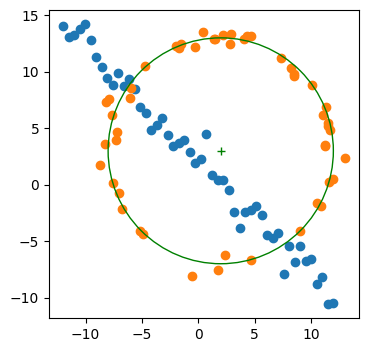

In [ ]:
true_line_normal = np.array([1, 1]) / np.sqrt(2) 
true_line_d = -2 / np.sqrt(2) 

true_circle_center = np.array([x0_gt, y0_gt])
true_circle_radius = r

fig, ax = plt.subplots(1, 1, figsize=(4, 4))
ax.scatter(X_line[:, 0], X_line[:, 1], label='Line')
ax.scatter(X_circ[:, 0], X_circ[:, 1], label='Circle')
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='g', fill=False, label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot((x0_gt), (y0_gt), '+', color='g')
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m * x_ + b



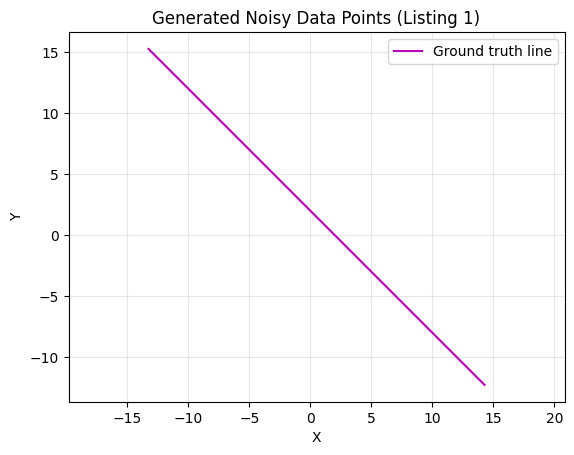

In [ ]:

plt.plot(x_, y_, color='m', label='Ground truth line')
plt.legend()
plt.title('Generated Noisy Data Points (Listing 1)')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()


In [ ]:
def point_to_line_distance(points, normal, d):
    return np.abs(points @ normal + d)

def fit_line_ransac(points, threshold=0.5, min_samples=2, max_iterations=1000):
    n_points = len(points)
    best_inliers = []
    best_normal = None
    best_d = None
    best_sample = None
    
    for iteration in range(max_iterations):
        sample_idx = np.random.choice(n_points, size=2, replace=False)
        sample_points = points[sample_idx]
        p1, p2 = sample_points[0], sample_points[1]
        normal = np.array([-(p2[1] - p1[1]), p2[0] - p1[0]])

        if np.linalg.norm(normal) < 1e-10:
            continue
            
        normal = normal / np.linalg.norm(normal) 
        d = -normal @ p1
        
        distances = point_to_line_distance(points, normal, d)
        inliers = np.where(distances <= threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_normal = normal
            best_d = d
            best_sample = sample_idx
    
    return best_normal, best_d, best_inliers, best_sample

line_normal, line_d, line_inliers, line_sample = fit_line_ransac(X, threshold=0.8, min_samples=2, max_iterations=1000)


In [ ]:
def point_to_circle_distance(points, center, radius):
    distances_to_center = np.linalg.norm(points - center, axis=1)
    return np.abs(distances_to_center - radius)

def fit_circle_from_three_points(p1, p2, p3):
    mid_ab = (p1 + p2) / 2
    mid_ac = (p1 + p3) / 2
    
    dir_ab = p2 - p1
    dir_ac = p3 - p1
    
    perp_ab = np.array([-dir_ab[1], dir_ab[0]])
    perp_ac = np.array([-dir_ac[1], dir_ac[0]])
    
    if np.linalg.norm(perp_ab) > 1e-10:
        perp_ab = perp_ab / np.linalg.norm(perp_ab)
    if np.linalg.norm(perp_ac) > 1e-10:
        perp_ac = perp_ac / np.linalg.norm(perp_ac)

    A = np.column_stack([perp_ab, -perp_ac])
    b = mid_ac - mid_ab
    
    try:
        solution = np.linalg.solve(A, b)
        t = solution[0]
        
        center = mid_ab + t * perp_ab
        
        radius = np.linalg.norm(p1 - center)
        
        return center, radius
    except np.linalg.LinAlgError:
        return None, None

def fit_circle_ransac(points, threshold=0.5, min_samples=3, max_iterations=1000):
    n_points = len(points)
    best_inliers = []
    best_center = None
    best_radius = None
    best_sample = None
    
    for iteration in range(max_iterations):
        sample_idx = np.random.choice(n_points, size=3, replace=False)
        sample_points = points[sample_idx]
        
        center, radius = fit_circle_from_three_points(sample_points[0], sample_points[1], sample_points[2])
        
        if center is None or radius is None:
            continue
            
        if radius < 0.1 or radius > 50:
            continue
        
        distances = point_to_circle_distance(points, center, radius)
        inliers = np.where(distances <= threshold)[0]
        
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_center = center
            best_radius = radius
            best_sample = sample_idx
    
    return best_center, best_radius, best_inliers, best_sample

remaining_points = X[~np.isin(np.arange(len(X)), line_inliers)]
print(f"Remaining points after removing line inliers: {len(remaining_points)}")

circle_center, circle_radius, circle_inliers_global, circle_sample_global = fit_circle_ransac(
    remaining_points, threshold=0.6, min_samples=3, max_iterations=1000)

circle_inliers = np.where(~np.isin(np.arange(len(X)), line_inliers))[0][circle_inliers_global]
circle_sample = np.where(~np.isin(np.arange(len(X)), line_inliers))[0][circle_sample_global]



Remaining points after removing line inliers: 56
RANSAC Circle Results:
Fitted circle: center (2.008, 3.110), radius 9.759
Number of circle inliers: 40
Circle sample points: [34 12 47]
True circle: center (2, 3), radius 10
Circle fitting error: 0.3513


C:\Users\HP\AppData\Local\Temp\ipykernel_6552\2743801372.py:41: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  plt.scatter(X[circle_sample, 0], X[circle_sample, 1], c='red', s=100, label='Best sample for circle', marker='o', facecolors='none', linewidth=3)
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


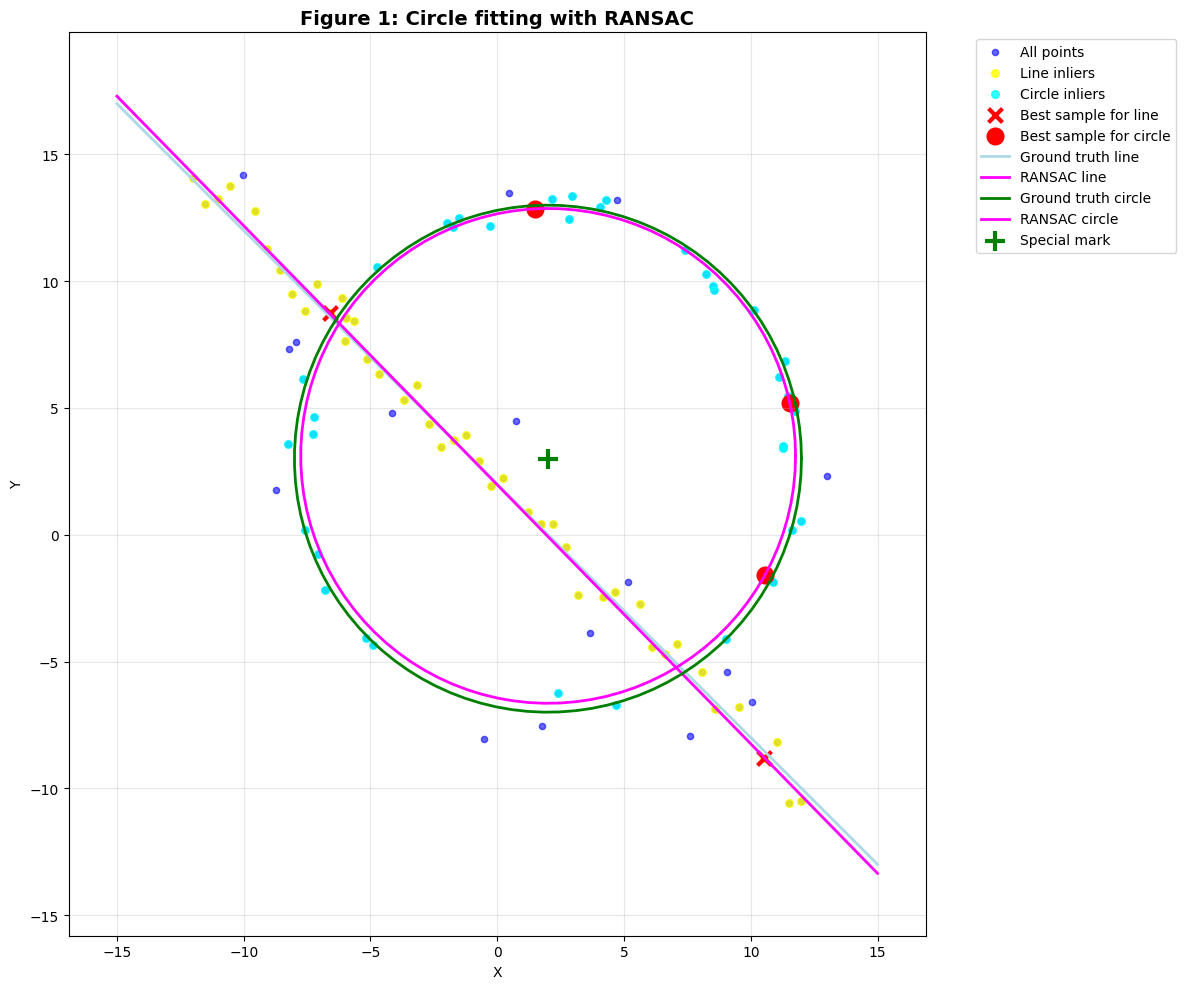

In [ ]:
def plot_line(x_range, normal, d, color, label, linestyle='-'):
    a, b = normal[0], normal[1]
    
    if abs(b) > 1e-10:
        y = -(a * x_range + d) / b
        plt.plot(x_range, y, color=color, label=label, linestyle=linestyle, linewidth=2)
    else:
        x_line = -d / a
        plt.axvline(x=x_line, color=color, label=label, linestyle=linestyle, linewidth=2)

def plot_circle(center, radius, color, label, linestyle='-'):
    theta = np.linspace(0, 2*np.pi, 100)
    x_circle = center[0] + radius * np.cos(theta)
    y_circle = center[1] + radius * np.sin(theta)
    plt.plot(x_circle, y_circle, color=color, label=label, linestyle=linestyle, linewidth=2)

plt.figure(figsize=(12, 10))
plt.scatter(X[:, 0], X[:, 1], c='blue', alpha=0.6, s=20, label='All points')
plt.scatter(X[line_inliers, 0], X[line_inliers, 1], c='yellow', s=30, label='Line inliers', alpha=0.8)
plt.scatter(X[circle_inliers, 0], X[circle_inliers, 1], c='cyan', s=30, label='Circle inliers', alpha=0.8)
plt.scatter(X[line_sample, 0], X[line_sample, 1], c='red', marker='x', s=100, label='Best sample for line', linewidth=3)
plt.scatter(X[circle_sample, 0], X[circle_sample, 1], c='red', s=100, label='Best sample for circle', marker='o', facecolors='none', linewidth=3)

x_range = np.linspace(-15, 15, 100)
plot_line(x_range, true_line_normal, true_line_d, 'lightblue', 'Ground truth line', linestyle='-')
plot_line(x_range, line_normal, line_d, 'magenta', 'RANSAC line', linestyle='-')
plot_circle(true_circle_center, true_circle_radius, 'green', 'Ground truth circle', linestyle='-')
plot_circle(circle_center, circle_radius, 'magenta', 'RANSAC circle', linestyle='-')
plt.scatter([x0_gt], [y0_gt], c='green', marker='+', s=200, linewidth=3, label='Special mark')

plt.title('Figure 1: Circle fitting with RANSAC', fontsize=14, fontweight='bold')
plt.xlabel('X')
plt.ylabel('Y')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axis('equal')
plt.xlim(-15, 15)
plt.ylim(-12, 16)
plt.tight_layout()
plt.show()



C:\Users\HP\AppData\Local\Temp\ipykernel_6552\805697016.py:25: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax1.scatter(X[circle_sample, 0], X[circle_sample, 1], c='red', s=100, label='Circle sample', marker='o', facecolors='none', linewidth=3)
C:\Users\HP\AppData\Local\Temp\ipykernel_6552\805697016.py:45: UserWarning: You passed both c and facecolor/facecolors for the markers. c has precedence over facecolor/facecolors. This behavior may change in the future.
  ax2.scatter(X[circle_first_sample, 0], X[circle_first_sample, 1], c='red', s=100, label='Circle sample', marker='o', facecolors='none', linewidth=3)
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits 

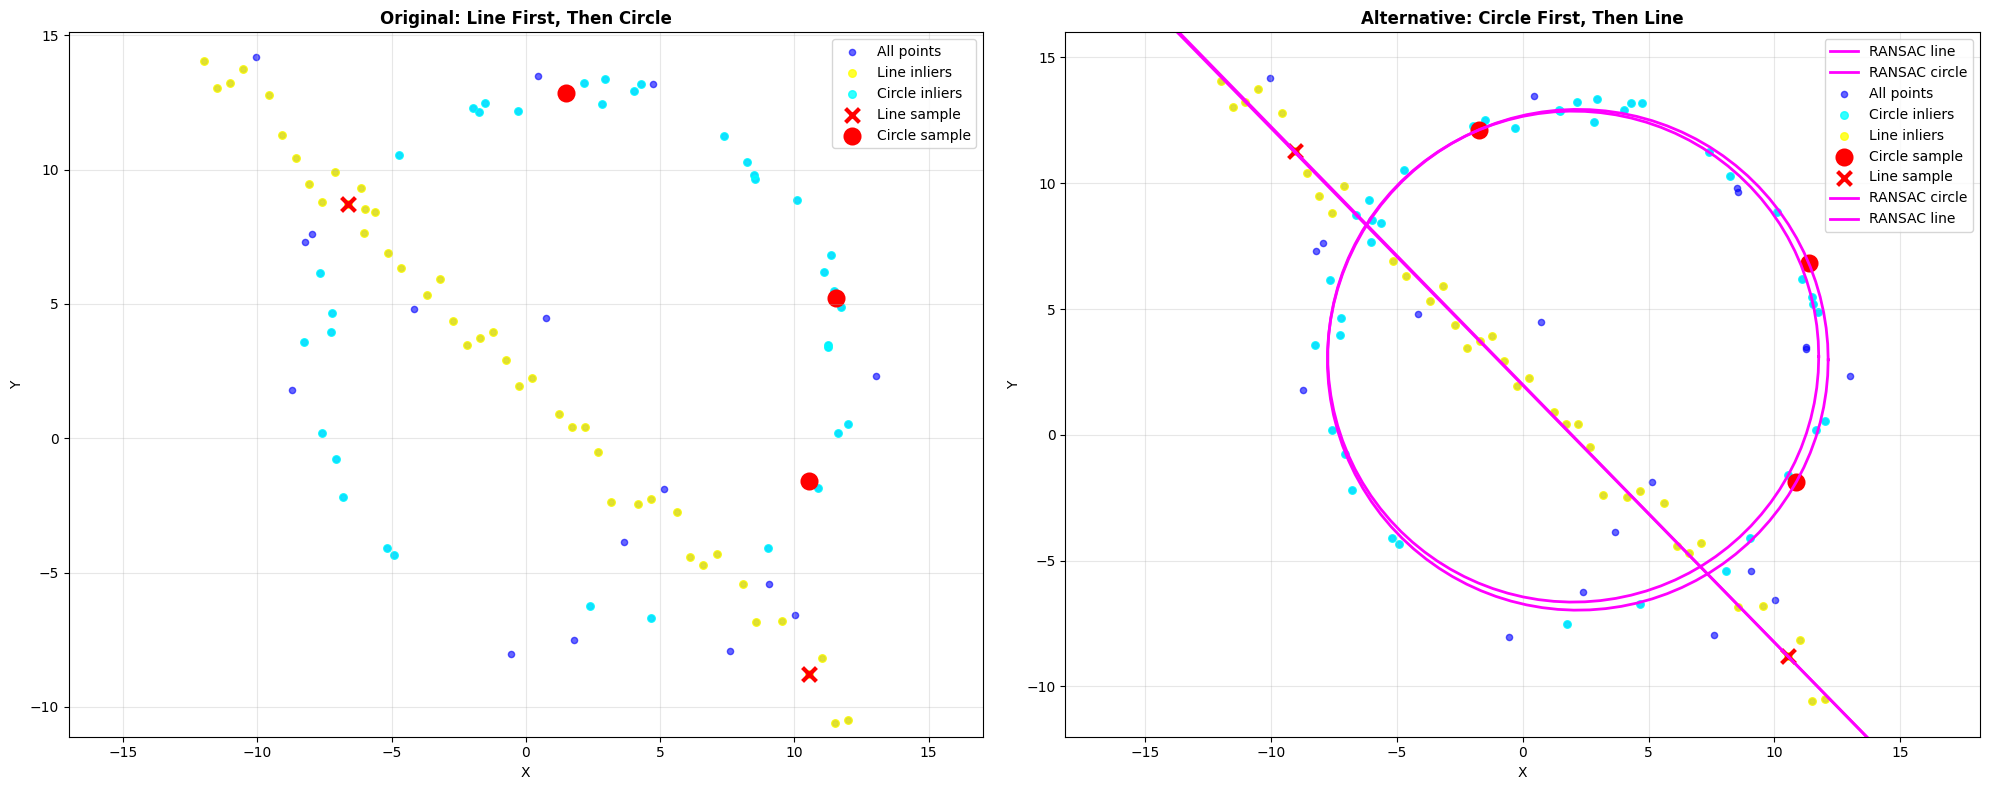

In [ ]:
circle_first_center, circle_first_radius, circle_first_inliers, circle_first_sample = fit_circle_ransac(
    X, threshold=0.6, min_samples=3, max_iterations=1000)
remaining_after_circle = X[~np.isin(np.arange(len(X)), circle_first_inliers)]

line_after_circle_normal, line_after_circle_d, line_after_circle_inliers, line_after_circle_sample = fit_line_ransac(
    remaining_after_circle, threshold=0.8, min_samples=2, max_iterations=1000)

line_after_circle_inliers_global = np.where(~np.isin(np.arange(len(X)), circle_first_inliers))[0][line_after_circle_inliers]
line_after_circle_sample_global = np.where(~np.isin(np.arange(len(X)), circle_first_inliers))[0][line_after_circle_sample]
circle_first_error = np.linalg.norm(circle_first_center - true_circle_center) + abs(circle_first_radius - true_circle_radius)
line_after_circle_error = np.linalg.norm(line_after_circle_normal - true_line_normal) + abs(line_after_circle_d - true_line_d)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

ax1.scatter(X[:, 0], X[:, 1], c='blue', alpha=0.6, s=20, label='All points')
ax1.scatter(X[line_inliers, 0], X[line_inliers, 1], c='yellow', s=30, label='Line inliers', alpha=0.8)
ax1.scatter(X[circle_inliers, 0], X[circle_inliers, 1], c='cyan', s=30, label='Circle inliers', alpha=0.8)
ax1.scatter(X[line_sample, 0], X[line_sample, 1], c='red', marker='x', s=100, label='Line sample', linewidth=3)
ax1.scatter(X[circle_sample, 0], X[circle_sample, 1], c='red', s=100, label='Circle sample', marker='o', facecolors='none', linewidth=3)

x_range = np.linspace(-15, 15, 100)
plot_line(x_range, line_normal, line_d, 'magenta', 'RANSAC line', linestyle='-')
plot_circle(circle_center, circle_radius, 'magenta', 'RANSAC circle', linestyle='-')

ax1.set_title('Original: Line First, Then Circle', fontsize=12, fontweight='bold')
ax1.set_xlabel('X')
ax1.set_ylabel('Y')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axis('equal')
ax1.set_xlim(-15, 15)
ax1.set_ylim(-12, 16)

ax2.scatter(X[:, 0], X[:, 1], c='blue', alpha=0.6, s=20, label='All points')
ax2.scatter(X[circle_first_inliers, 0], X[circle_first_inliers, 1], c='cyan', s=30, label='Circle inliers', alpha=0.8)
ax2.scatter(X[line_after_circle_inliers_global, 0], X[line_after_circle_inliers_global, 1], c='yellow', s=30, label='Line inliers', alpha=0.8)
ax2.scatter(X[circle_first_sample, 0], X[circle_first_sample, 1], c='red', s=100, label='Circle sample', marker='o', facecolors='none', linewidth=3)
ax2.scatter(X[line_after_circle_sample_global, 0], X[line_after_circle_sample_global, 1], c='red', marker='x', s=100, label='Line sample', linewidth=3)

plot_circle(circle_first_center, circle_first_radius, 'magenta', 'RANSAC circle', linestyle='-')
plot_line(x_range, line_after_circle_normal, line_after_circle_d, 'magenta', 'RANSAC line', linestyle='-')

ax2.set_title('Alternative: Circle First, Then Line', fontsize=12, fontweight='bold')
ax2.set_xlabel('X')
ax2.set_ylabel('Y')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.axis('equal')
ax2.set_xlim(-15, 15)
ax2.set_ylim(-12, 16)

plt.tight_layout()
plt.show()

